# Home Credit Default Risk
## Notebook 01 - Data Loading and Understanding

### Objectives
- Understand the business problem
- Understand dataset structure
- Identify target variable
- Assess dataset quality
- Prepare for Exploratory Data Analysis

## Business Understanding

Home Credit provides loans to customers who may have limited credit history.
The objective is to predict whether a customer will experience payment difficulties.

- **TARGET = 1** → Customer had payment difficulties (default)
- **TARGET = 0** → Customer repaid successfully

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
train = pd.read_csv("../data/application_train.csv")
print(f"Dataset loaded: {train.shape[0]:,} rows, {train.shape[1]} columns")

Dataset loaded: 307,511 rows, 122 columns


In [4]:
# Dataset shape
print(f"Rows    : {train.shape[0]:,}")
print(f"Columns : {train.shape[1]}")
print(f"\nGrain: One row = One loan application")

Rows    : 307,511
Columns : 122

Grain: One row = One loan application


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [6]:
print(train["TARGET"].value_counts())
print()
print(train["TARGET"].value_counts(normalize=True) * 100)

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


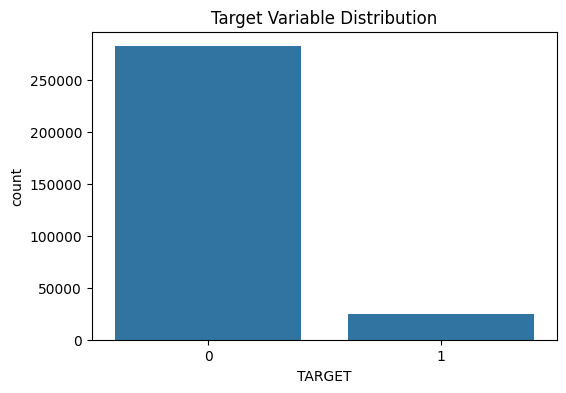

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="TARGET", data=train)
plt.title("Target Variable Distribution")
plt.show()

## Observation: Target Variable

- 91.93% customers successfully repaid loans (TARGET = 0)
- 8.07% customers experienced payment difficulties (TARGET = 1)
- Dataset is **highly imbalanced**
- Accuracy alone is a misleading metric for imbalanced datasets
- Better metrics: Precision, Recall, F1, ROC-AUC

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [9]:
print(train["CNT_CHILDREN"].value_counts().head(10))

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
Name: count, dtype: int64


## Observation: CNT_CHILDREN

- 99.7% of applicants have 0–3 children
- Values of 14 and 19 exist with a gap between 8 and 14
- Gap in values suggests these are data entry errors
- Action: Cap CNT_CHILDREN at 5 in data cleaning phase

In [10]:
print(f"Mean     : {train['AMT_INCOME_TOTAL'].mean():,.0f}")
print(f"Median   : {train['AMT_INCOME_TOTAL'].median():,.0f}")
print(f"Skewness : {train['AMT_INCOME_TOTAL'].skew():.4f}")
print(f"Kurtosis : {train['AMT_INCOME_TOTAL'].kurt():.4f}")

Mean     : 168,798
Median   : 147,150
Skewness : 391.5597
Kurtosis : 191786.5544


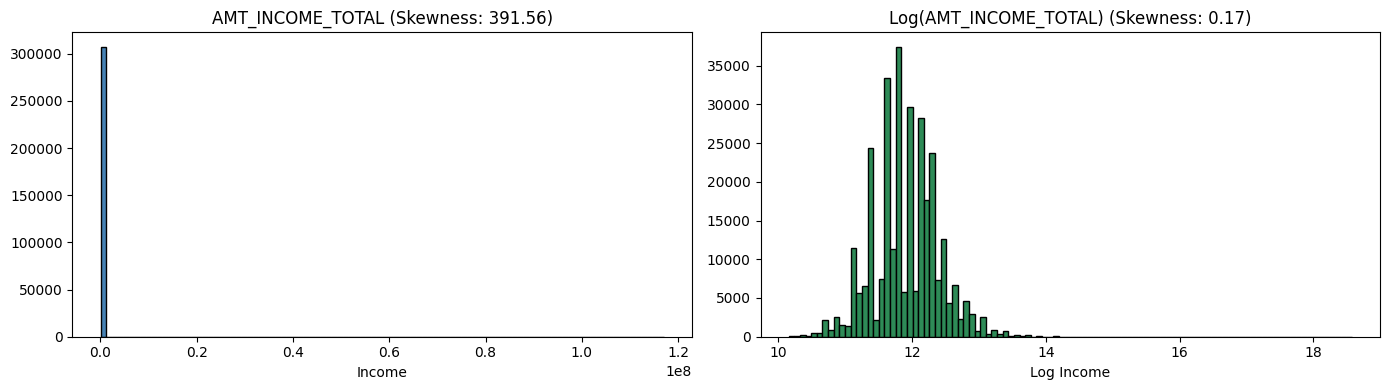

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['AMT_INCOME_TOTAL'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title(f'AMT_INCOME_TOTAL (Skewness: {train["AMT_INCOME_TOTAL"].skew():.2f})')
axes[0].set_xlabel('Income')

log_income = np.log1p(train['AMT_INCOME_TOTAL'])
axes[1].hist(log_income, bins=100, color='seagreen', edgecolor='black')
axes[1].set_title(f'Log(AMT_INCOME_TOTAL) (Skewness: {log_income.skew():.2f})')
axes[1].set_xlabel('Log Income')

plt.tight_layout()
plt.show()

In [12]:
numeric_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

for col in numeric_cols:
    print(f"{col}")
    print(f"  Mean     : {train[col].mean():,.0f}")
    print(f"  Median   : {train[col].median():,.0f}")
    print(f"  Skewness : {train[col].skew():.4f}")
    print(f"  Kurtosis : {train[col].kurt():.4f}")
    print()

AMT_INCOME_TOTAL
  Mean     : 168,798
  Median   : 147,150
  Skewness : 391.5597
  Kurtosis : 191786.5544

AMT_CREDIT
  Mean     : 599,026
  Median   : 513,531
  Skewness : 1.2348
  Kurtosis : 1.9340

AMT_ANNUITY
  Mean     : 27,109
  Median   : 24,903
  Skewness : 1.5798
  Kurtosis : 7.7073

AMT_GOODS_PRICE
  Mean     : 538,396
  Median   : 450,000
  Skewness : 1.3490
  Kurtosis : 2.4319



## Observation: Skewness & Kurtosis

| Column | Skewness | Kurtosis | Action |
|---|---|---|---|
| AMT_INCOME_TOTAL | 391.56 | 191,786 | Remove outliers, log transform |
| AMT_CREDIT | 1.23 | 1.93 | Log transform for modeling |
| AMT_ANNUITY | 1.58 | 7.71 | Investigate outliers |
| AMT_GOODS_PRICE | 1.35 | 2.43 | Log transform for modeling |

All financial columns are right-skewed. Mean is misleading — use median for reporting.

In [13]:
# Manual skewness calculation
x = train['AMT_INCOME_TOTAL']
mean = x.mean()
std = x.std()

standardized = (x - mean) / std
manual_skewness = (standardized**3).mean()

print(f"Manual Skewness : {manual_skewness:.4f}")
print(f"Pandas Skewness : {x.skew():.4f}")

Manual Skewness : 391.5558
Pandas Skewness : 391.5597


In [14]:
x = train['AMT_INCOME_TOTAL']

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = train[(x < lower_fence) | (x > upper_fence)]

print(f"Q1            : {Q1:,.0f}")
print(f"Q3            : {Q3:,.0f}")
print(f"IQR           : {IQR:,.0f}")
print(f"Lower Fence   : {lower_fence:,.0f}")
print(f"Upper Fence   : {upper_fence:,.0f}")
print(f"Total Outliers: {len(outliers):,}")
print(f"Outlier %     : {len(outliers)/len(train)*100:.2f}%")

Q1            : 112,500
Q3            : 202,500
IQR           : 90,000
Lower Fence   : -22,500
Upper Fence   : 337,500
Total Outliers: 14,035
Outlier %     : 4.56%


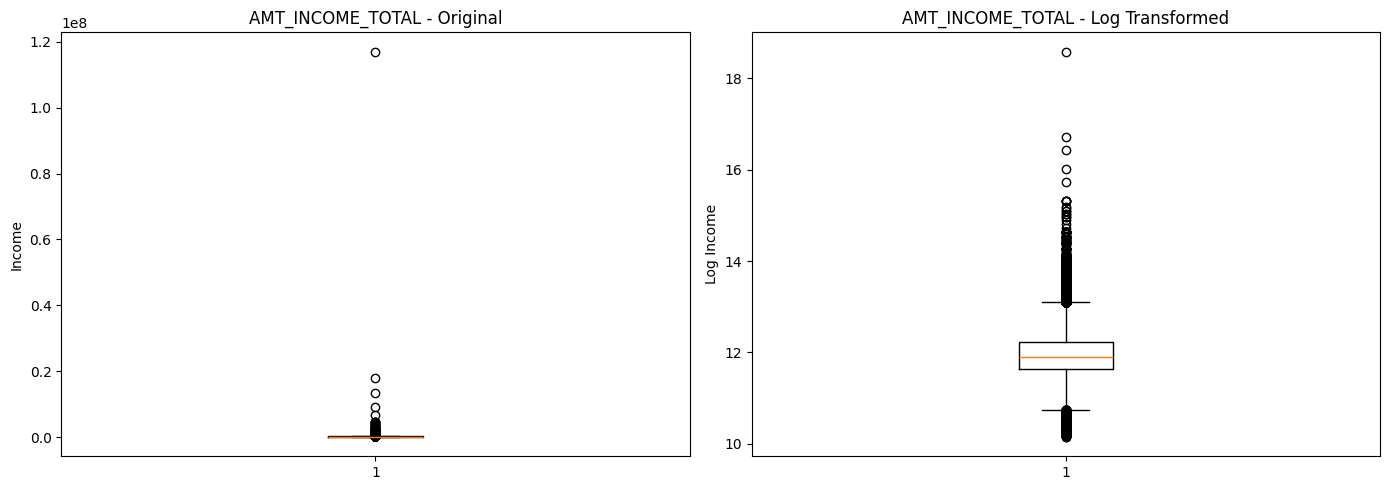

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(train['AMT_INCOME_TOTAL'], vert=True)
axes[0].set_title('AMT_INCOME_TOTAL - Original')
axes[0].set_ylabel('Income')

axes[1].boxplot(np.log1p(train['AMT_INCOME_TOTAL']), vert=True)
axes[1].set_title('AMT_INCOME_TOTAL - Log Transformed')
axes[1].set_ylabel('Log Income')

plt.tight_layout()
plt.show()

## Observation: IQR & Boxplot Analysis

- Q1: 112,500 | Q3: 202,500 | IQR: 90,000
- Upper Fence: 337,500
- Outliers: 14,035 applicants (4.56%) earn above upper fence
- Boxplot visually confirms extreme right skew
- Log transformation improves readability but does not remove outliers
- Outlier treatment will be handled in Notebook 05

In [16]:
print(train['DAYS_BIRTH'].describe())
print(f"\nSample values: {train['DAYS_BIRTH'].head().tolist()}")

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

Sample values: [-9461, -16765, -19046, -19005, -19932]


In [17]:
# Convert DAYS_BIRTH to age in years
train['AGE_YEARS'] = abs(train['DAYS_BIRTH']) / 365

print(f"Youngest applicant : {train['AGE_YEARS'].min():.1f} years")
print(f"Oldest applicant   : {train['AGE_YEARS'].max():.1f} years")
print(f"Average age        : {train['AGE_YEARS'].mean():.1f} years")
print(f"Median age         : {train['AGE_YEARS'].median():.1f} years")

Youngest applicant : 20.5 years
Oldest applicant   : 69.1 years
Average age        : 43.9 years
Median age         : 43.2 years


C:\Users\devir\AppData\Local\Temp\ipykernel_4412\470778587.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['AGE_YEARS'] = abs(train['DAYS_BIRTH']) / 365


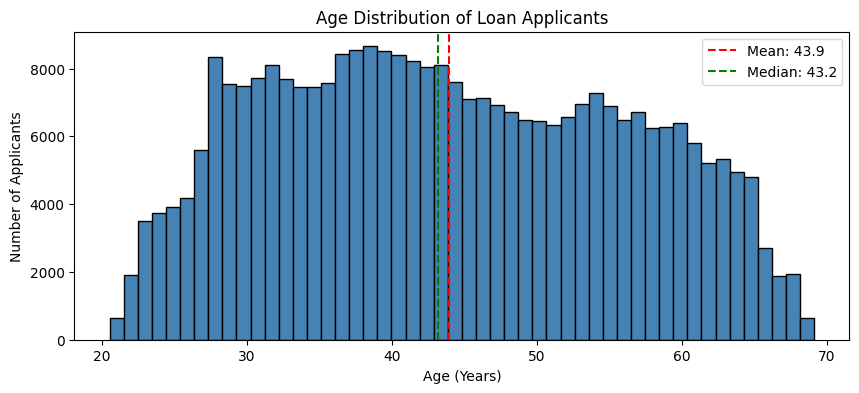

In [18]:
plt.figure(figsize=(10, 4))

plt.hist(train['AGE_YEARS'], bins=50, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Loan Applicants')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Applicants')
plt.axvline(train['AGE_YEARS'].mean(), color='red', linestyle='--', label=f"Mean: {train['AGE_YEARS'].mean():.1f}")
plt.axvline(train['AGE_YEARS'].median(), color='green', linestyle='--', label=f"Median: {train['AGE_YEARS'].median():.1f}")
plt.legend()
plt.show()

## Observation: DAYS_BIRTH → AGE_YEARS

- DAYS_BIRTH stored as negative integers (days before application)
- Converted to AGE_YEARS using: abs(DAYS_BIRTH) / 365
- Age range: 20.5 to 69.1 years — all valid, no outliers
- Mean (43.9) ≈ Median (43.2) — age is approximately normally distributed
- Peak applicant age: 35–45 years
- No data quality issues found in this column
- Business question for Notebook 06: Do younger applicants default more?

In [19]:
categorical_cols = train.select_dtypes(include='object').columns.tolist()
print(f"Total categorical columns: {len(categorical_cols)}")
print()
for col in categorical_cols:
    print(f"{col}: {train[col].nunique()} unique values")

C:\Users\devir\AppData\Local\Temp\ipykernel_4412\1372393004.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include='object').columns.tolist()


Total categorical columns: 16

NAME_CONTRACT_TYPE: 2 unique values
CODE_GENDER: 3 unique values
FLAG_OWN_CAR: 2 unique values
FLAG_OWN_REALTY: 2 unique values
NAME_TYPE_SUITE: 7 unique values
NAME_INCOME_TYPE: 8 unique values
NAME_EDUCATION_TYPE: 5 unique values
NAME_FAMILY_STATUS: 6 unique values
NAME_HOUSING_TYPE: 6 unique values
OCCUPATION_TYPE: 18 unique values
WEEKDAY_APPR_PROCESS_START: 7 unique values
ORGANIZATION_TYPE: 58 unique values
FONDKAPREMONT_MODE: 4 unique values
HOUSETYPE_MODE: 3 unique values
WALLSMATERIAL_MODE: 7 unique values
EMERGENCYSTATE_MODE: 2 unique values


In [20]:
categorical_cols = train.select_dtypes(include='str').columns.tolist()
print(f"Total categorical columns: {len(categorical_cols)}")
print()
for col in categorical_cols:
    print(f"{col}: {train[col].nunique()} unique values")

Total categorical columns: 16

NAME_CONTRACT_TYPE: 2 unique values
CODE_GENDER: 3 unique values
FLAG_OWN_CAR: 2 unique values
FLAG_OWN_REALTY: 2 unique values
NAME_TYPE_SUITE: 7 unique values
NAME_INCOME_TYPE: 8 unique values
NAME_EDUCATION_TYPE: 5 unique values
NAME_FAMILY_STATUS: 6 unique values
NAME_HOUSING_TYPE: 6 unique values
OCCUPATION_TYPE: 18 unique values
WEEKDAY_APPR_PROCESS_START: 7 unique values
ORGANIZATION_TYPE: 58 unique values
FONDKAPREMONT_MODE: 4 unique values
HOUSETYPE_MODE: 3 unique values
WALLSMATERIAL_MODE: 7 unique values
EMERGENCYSTATE_MODE: 2 unique values


In [21]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(train[col].value_counts().head(5))


NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR:
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY:
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE:
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Name: count, dtype: int64

NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Name: count, dtype: int64

NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree  

## Observation: Categorical Columns Overview

- 16 categorical columns identified
- Binary columns (2 values): NAME_CONTRACT_TYPE, FLAG_OWN_CAR, FLAG_OWN_REALTY, EMERGENCYSTATE_MODE
- Low cardinality (3-8 values): CODE_GENDER, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS etc.
- High cardinality (18-58 values): OCCUPATION_TYPE (18), ORGANIZATION_TYPE (58)

Data Quality Issues Found:
- CODE_GENDER has 4 records with value 'XNA' — needs treatment in cleaning phase
- ORGANIZATION_TYPE has 58 categories — needs grouping in feature engineering

Business Notes:
- 65.8% female applicants — unusual gender distribution
- 69% own property — majority are asset holders
- 90.5% cash loans vs 9.5% revolving loans

## Notebook 01 Summary — Data Loading & Understanding

### Dataset
- 307,511 loan applications | 122 features
- Large dataset suitable for statistical analysis

### Key Findings
- Target: 8.07% default rate — highly imbalanced dataset
- AMT_INCOME_TOTAL: Extreme skewness (391.56) due to outliers up to 117M
- CNT_CHILDREN: Values of 14 and 19 are likely data entry errors
- AGE_YEARS: Clean column, range 20–69, normally distributed
- 16 categorical columns identified, CODE_GENDER has 4 XNA values

### Next Steps
- Notebook 02: Data Quality Assessment — missing values, duplicates, data types